In [ ]:
# importing the library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# Load the dataset
df = pd.read_csv("C:/Users/temp.admin/Documents/Stats AIDS/diabetes.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:", df.shape)

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Shape: (768, 9)


In [ ]:
#Select the Target and predictor variables
X = df[[
    "Pregnancies",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]]

y = df["Glucose"]

print("Predictor Variables:")
print(X.head())

print("\nTarget Variable:")
print(y.head())

Predictor Variables:
   Pregnancies  BloodPressure  SkinThickness  Insulin   BMI  \
0            6             72             35        0  33.6   
1            1             66             29        0  26.6   
2            8             64              0        0  23.3   
3            1             66             23       94  28.1   
4            0             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
4                     2.288   33  

Target Variable:
0    148
1     85
2    183
3     89
4    137
Name: Glucose, dtype: int64


In [ ]:
# checking and preprocess missing or invalid values

# Replace invalid zeros in predictor columns
invalid_columns = [
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

X[invalid_columns] = X[invalid_columns].replace(0, np.nan)

# Fill missing predictor values with the median
X = X.fillna(X.median())

# Remove rows where the target value is missing or zero
valid_rows = y.notna() & (y != 0)

X = X.loc[valid_rows]
y = y.loc[valid_rows]

print("Missing values in predictors:")
print(X.isnull().sum())

print("\nRemaining rows:", len(X))

Missing values in predictors:
Pregnancies                 0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64

Remaining rows: 763


C:\Users\temp.admin\AppData\Local\Temp\ipykernel_16936\4267724578.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[invalid_columns] = X[invalid_columns].replace(0, np.nan)


In [ ]:
# Divide the datset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (610, 7)
Testing data: (153, 7)


In [ ]:
# develop and train the regression model
model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [ ]:
# generate predictions
y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Actual Glucose": y_test,
    "Predicted Glucose": y_pred
})

print(results.head(10))

     Actual Glucose  Predicted Glucose
361             158         133.216375
261             141         116.484932
754             154         126.457322
195             158         134.058121
335             165         141.233229
590             111         136.725792
760              88          95.908285
138             129         120.954890
67              109         143.959304
222             119         115.898095


In [ ]:
# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 Score:", r2)

Mean Absolute Error (MAE): 19.33279118281509
Mean Squared Error (MSE): 646.8558768053962
Root Mean Squared Error (RMSE): 25.433361492445236
R2 Score: 0.299917388646184


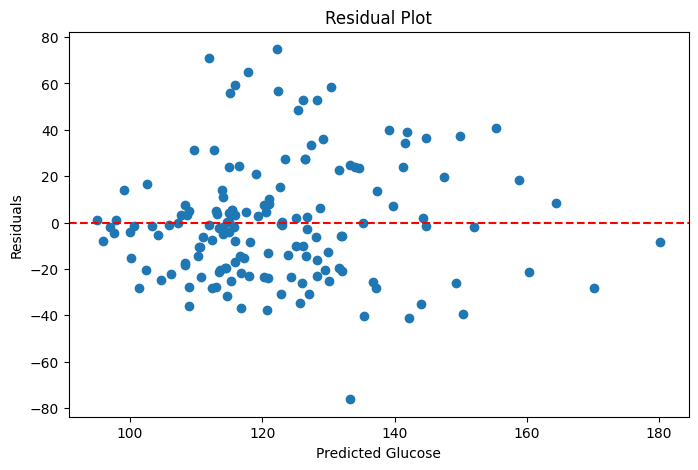

In [ ]:
# analyze residuals
residuals = y_test - y_pred

# Residual plot
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted Glucose")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

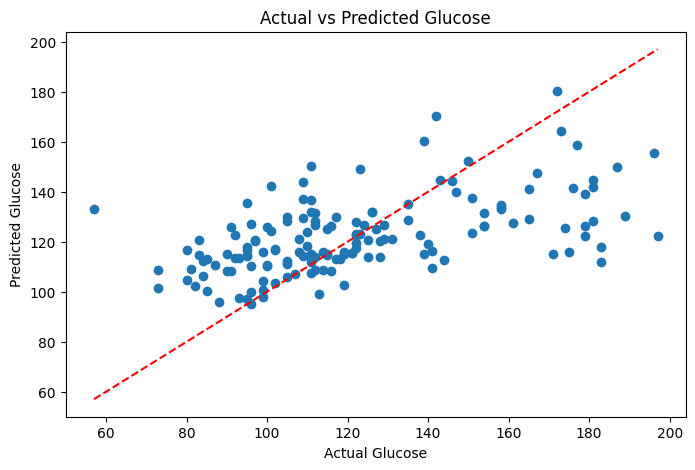

In [ ]:
# comapre actual and predicted values
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

# Reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Actual Glucose")
plt.ylabel("Predicted Glucose")
plt.title("Actual vs Predicted Glucose")
plt.show()

In [12]:
# ## Interpretation:

# The MAE of 19.33 indicates that the model's predictions differ from the actual Glucose values by approximately 19.33 units on average.

# The MSE of 646.86 represents the average squared prediction error.

# The RMSE of 25.43 indicates that the typical prediction error is around 25.43 Glucose units, with larger errors having a greater effect.

# The R² Score of 0.2999 means that the model explains approximately 30% of the variation in Glucose levels.

# The model has limited predictive performance, as a considerable amount of variation in Glucose levels remains unexplained.